# Log-normal Q-Q plots – dD = dV og dD = c

Visuel analyse af om terminalhastighederne følger en log-normalfordeling.  
Alle ni grupper (3 materialer × 3 sigteintervaller) vises i et 3×3-gitter for hvert valg af karakteristisk diameter.

**Materialer:** Epoxy (Choko-bob), POM, TPU  
**Sigteintervaller:** 1,8–4 mm, 4–6,3 mm, 6,3–8 mm  
**Fordeling testet:** log-normal (ln *v* plottes mod normale teoretiske kvantiler)

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import probplot

rho_f = 998.2
mu_f  = 1.0016e-3
nu    = mu_f / rho_f
g     = 9.82

rho_Epoxy  = 1926
rho_POM = 1504
rho_TPU = 1200

COLORS = {"Epoxy": "#7B3F00", "POM": "#E8873A", "TPU": "#000000"}
print('Konstanter og farver indlæst')

Konstanter og farver indlæst


In [ ]:
def Cd_Goral(Re, psi):
    Gamma   = 1 + (3.2 / math.sqrt(Re)) + (32 / Re)
    Ypsilon = min(0.44 * psi**-2, 1)
    return Gamma * Ypsilon

def terminal_velocity(a, b, c, m, psi, rho_p, dD='dV', v0=0.05, iters=100):
    s      = rho_p / rho_f
    V      = m / rho_p
    dp     = math.sqrt(a * b)
    dV     = (6 * V / math.pi) ** (1/3)
    dD_val = {'dV': dV, 'c': c}.get(dD, dV)
    v = v0
    for _ in range(iters):
        Re = dp * v / nu
        Cd = Cd_Goral(Re, psi)
        v  = math.sqrt((4 * g * (s - 1) * dD_val) / (3 * Cd))
    return v

def get_velocities(data_mm, rho_p, dD='dV'):
    df = pd.DataFrame(data_mm, columns=['c', 'b', 'a', 'm']) / 1000
    df['psi'] = (df['c']**2 / (df['b'] * df['a'])) ** (1/3)
    return np.array([
        terminal_velocity(r.a, r.b, r.c, r.m, r.psi, rho_p, dD)
        for _, r in df.iterrows()
    ])


Funktioner indlæst


In [ ]:
Epoxy_1_8 = [
    [1.89,3.73,10.33,0.0488],[2.51,4.52,5.60,0.0489],[3.02,4.20,7.55,0.0515],
    [3.63,3.68,6.50,0.0578],[3.20,4.48,10.02,0.0834],[2.27,4.22,7.35,0.0448],
    [3.43,4.17,5.71,0.0511],[3.08,4.31,6.54,0.0630],[2.60,4.66,7.47,0.0594],
    [2.99,4.27,8.74,0.0633],[2.45,3.96,11.55,0.0553],[2.22,4.16,5.92,0.0481],
    [2.64,5.46,6.31,0.0518],[2.47,3.16,5.93,0.0407],[2.42,5.23,6.89,0.0484],
    [1.48,5.24,8.64,0.0383],[1.62,4.25,9.65,0.0515],[1.69,5.24,6.63,0.0382],
    [2.67,4.80,7.92,0.0664],[4.03,4.23,7.25,0.0881],[2.75,2.94,6.98,0.0445],
    [1.82,4.37,6.35,0.0391],[3.16,3.46,6.32,0.0595],[2.36,4.57,8.39,0.0677],
    [1.89,4.01,6.80,0.0412],
]
Epoxy_4 = [
    [4.88,5.53,9.99,0.2654],[4.64,7.28,11.01,0.2251],[3.43,7.39,11.25,0.1844],
    [3.46,4.82,8.00,0.1056],[2.49,5.28,8.81,0.0746],[4.16,4.36,7.70,0.0774],
    [3.40,5.90,7.63,0.1134],[4.42,4.76,8.19,0.1330],[4.51,5.54,7.97,0.1104],
    [4.45,6.91,9.61,0.1942],[5.54,6.14,14.35,0.3560],[4.90,5.92,8.57,0.2283],
    [2.49,5.05,6.14,0.0533],[4.08,6.39,9.76,0.1501],[5.08,6.04,9.32,0.2326],
    [5.82,6.42,11.54,0.3616],[3.84,8.37,13.59,0.3051],[4.76,6.16,9.08,0.1598],
    [4.64,5.04,11.09,0.1965],[4.72,6.11,7.73,0.1584],[4.72,6.43,9.69,0.1778],
    [4.21,6.44,13.45,0.2295],[5.06,6.35,8.22,0.1662],[3.79,4.73,11.22,0.1181],
    [4.17,5.31,7.74,0.1221],
]
Epoxy_6_3 = [
    [5.13,6.83,9.46,0.2793],[5.17,8.98,12.49,0.3811],[5.45,8.83,13.18,0.6560],
    [5.59,7.44,12.21,0.3900],[6.35,6.56,12.57,0.4503],[3.48,9.30,12.98,0.2441],
    [5.73,9.98,13.47,0.4968],[6.42,6.62,11.92,0.5399],[2.61,8.76,10.60,0.2103],
    [4.65,8.02,11.58,0.4227],[6.82,7.52,13.68,0.6593],[4.89,8.07,15.39,0.4290],
    [5.40,6.69,10.31,0.2440],[5.67,6.75,12.37,0.4486],[3.91,8.16,13.72,0.4238],
    [6.25,10.29,14.19,0.5766],[6.35,9.17,11.95,0.4906],[4.54,7.11,10.04,0.2726],
    [5.74,7.02,11.72,0.4003],[4.17,10.90,14.48,0.4518],[5.87,6.51,12.21,0.4074],
    [7.31,8.09,11.84,0.6765],[7.39,8.34,11.39,0.5233],[6.59,8.04,10.90,0.4935],
    [5.90,7.24,12.12,0.4168],
]
POM_1_8 = [
    [2.17,6.11,8.66,0.0585],[2.73,3.29,7.20,0.0636],[3.78,5.08,7.76,0.0692],
    [3.15,5.50,8.97,0.0890],[3.63,4.31,7.95,0.0919],[3.02,4.01,6.21,0.0560],
    [3.61,3.91,6.77,0.0669],[3.20,4.26,5.98,0.0455],[3.87,4.49,6.96,0.0764],
    [2.79,4.00,7.81,0.0550],[3.16,3.79,5.52,0.0380],[2.92,3.42,5.76,0.0438],
    [3.11,3.90,5.21,0.0433],[4.00,4.40,10.62,0.0682],[3.48,4.17,7.55,0.0081],
    [3.20,3.87,5.48,0.0429],[3.53,3.99,6.53,0.0623],[3.38,3.85,7.94,0.0766],
    [3.76,4.17,5.80,0.0479],[3.89,5.84,7.15,0.0625],[2.90,4.20,7.88,0.0650],
    [3.23,4.07,9.58,0.0755],[2.43,3.30,4.80,0.0232],[2.66,4.19,6.31,0.0467],
    [3.29,3.90,7.33,0.0640],
]
POM_4 = [
    [3.51,4.93,6.24,0.0782],[4.23,5.54,6.33,0.0954],[3.35,6.44,9.67,0.1549],
    [3.17,5.58,9.02,0.0872],[3.78,6.28,6.88,0.0998],[4.14,5.36,5.69,0.1034],
    [3.64,6.77,7.38,0.0929],[4.48,5.09,7.18,0.1192],[4.52,6.51,10.56,0.1870],
    [5.70,5.84,7.65,0.1611],[4.30,5.38,6.53,0.0947],[5.79,6.71,8.61,0.1719],
    [5.18,5.53,8.62,0.1755],[5.25,5.98,8.19,0.1525],[4.02,6.66,10.09,0.1576],
    [3.45,5.06,7.81,0.0941],[3.75,7.63,9.37,0.1814],[5.10,7.55,11.78,0.2169],
    [4.43,6.13,7.34,0.1252],[4.35,5.28,8.46,0.1401],[3.09,5.46,8.22,0.0731],
    [5.56,5.63,7.77,0.1517],[4.48,6.60,7.58,0.1384],[5.23,5.78,8.64,0.1769],
    [4.22,5.83,8.76,0.1360],
]
POM_6_3 = [
    [5.84,7.21,9.04,0.2518],[5.72,10.15,15.55,0.4969],[5.27,9.22,11.30,0.3411],
    [5.54,6.52,9.31,0.2426],[5.54,7.67,10.80,0.2982],[5.73,9.61,11.17,0.4174],
    [5.04,5.28,11.08,0.2255],[5.17,9.54,9.98,0.2754],[5.04,8.11,10.28,0.2747],
    [4.79,9.13,11.42,0.1999],[5.92,6.56,12.21,0.2557],[5.51,7.22,10.46,0.2522],
    [5.89,7.98,10.18,0.3147],[5.80,6.93,11.09,0.2900],[5.41,6.71,10.67,0.2875],
    [6.93,9.25,12.06,0.3792],[6.07,7.41,10.74,0.3279],[4.56,7.74,11.06,0.2452],
    [5.46,8.05,9.21,0.2625],[4.87,8.50,12.64,0.3077],[5.44,7.11,9.37,0.2200],
    [5.71,7.19,8.80,0.2465],[5.50,7.44,10.08,0.3035],[5.43,7.25,10.34,0.2730],
    [5.30,7.51,11.13,0.3447],
]
TPU_1_8 = [
    [2.10,4.95,9.44,0.0505],[2.11,4.61,7.31,0.0462],[2.15,4.71,9.24,0.0386],
    [2.16,4.06,8.95,0.0498],[2.23,4.08,9.83,0.0526],[2.44,4.78,11.11,0.0344],
    [2.19,4.11,6.98,0.0359],[2.27,3.79,6.90,0.0320],[2.16,5.23,9.02,0.0333],
    [2.07,3.57,7.85,0.0282],[2.37,4.37,7.76,0.0428],[1.19,2.78,11.33,0.0308],
    [2.21,4.45,7.17,0.0364],[3.22,4.92,9.73,0.0553],[2.77,3.66,9.81,0.0652],
    [2.85,3.47,7.36,0.0338],[2.63,4.24,6.70,0.0405],[2.06,4.42,11.54,0.0813],
    [2.26,4.53,8.70,0.0520],[2.10,4.46,7.92,0.0433],[2.58,3.68,13.89,0.0772],
    [2.53,2.66,8.83,0.0282],[3.18,3.60,6.04,0.0403],[2.94,3.00,8.30,0.0288],
    [2.16,4.96,9.28,0.0497],
]
TPU_4 = [
    [2.51,7.48,12.92,0.1101],[2.23,7.04,10.79,0.0680],[2.00,4.95,6.08,0.0399],
    [2.43,8.04,12.22,0.1399],[2.22,4.99,7.44,0.0582],[3.29,5.58,9.49,0.0840],
    [2.20,6.13,8.62,0.0882],[2.18,7.00,12.94,0.1094],[2.16,5.67,10.55,0.0772],
    [2.11,5.47,9.68,0.0735],[2.23,4.40,8.88,0.0496],[2.09,6.19,7.99,0.0495],
    [3.34,7.79,11.06,0.1136],[2.24,5.17,7.72,0.0569],[3.19,9.72,11.66,0.0947],
    [2.14,6.18,8.48,0.0603],[2.71,7.22,9.86,0.0886],[2.15,6.97,10.93,0.0775],
    [1.48,5.86,9.76,0.0489],[2.18,6.89,11.00,0.0940],[2.19,5.92,9.80,0.0625],
    [2.14,7.06,9.77,0.0789],[2.22,4.28,10.40,0.0703],[2.17,5.27,9.21,0.0597],
    [2.29,5.96,11.14,0.0816],
]
TPU_6_3 = [
    [2.19,9.27,10.62,0.1205],[2.14,10.78,12.96,0.1785],[2.45,8.29,10.85,0.1429],
    [2.28,11.29,12.99,0.2040],[2.27,9.56,14.26,0.1893],[2.25,9.04,11.58,0.1522],
    [2.22,7.68,12.65,0.1134],[2.22,7.57,10.94,0.1275],[2.32,8.28,14.02,0.1492],
    [2.21,8.85,10.65,0.1162],[2.26,9.71,13.55,0.1836],[2.13,8.83,10.19,0.1182],
    [2.12,9.46,15.84,0.2063],[2.12,8.07,14.80,0.1470],[2.21,10.80,13.98,0.1450],
    [2.27,9.69,16.87,0.2332],[2.21,8.30,11.33,0.1320],[3.28,7.99,11.79,0.1280],
    [2.24,9.14,10.27,0.1189],[2.40,8.01,11.61,0.1295],[2.21,8.34,13.37,0.1426],
    [2.18,7.64,11.12,0.1121],[2.19,9.10,12.60,0.1405],[2.27,9.03,11.96,0.1342],
    [3.19,8.26,11.35,0.0970],
]

RAW = {
    'Epoxy': ([Epoxy_1_8,  Epoxy_4,  Epoxy_6_3],  rho_Epoxy),
    'POM':   ([POM_1_8, POM_4, POM_6_3], rho_POM),
    'TPU':   ([TPU_1_8, TPU_4, TPU_6_3], rho_TPU),
}

print('Data indlæst')

Data indlæst


In [5]:
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.35,
    'grid.linestyle':    '--',
})

MATS   = ['Epoxy', 'POM', 'TPU']
SIEVES = ['1,8-4 mm', '4-6,3 mm', '6,3-8 mm']

def plot_lognormal_qq(ax, v, color):
    ln_v = np.log(v)
    (osm, osr), (slope, intercept, _) = probplot(ln_v, dist='norm')
    ax.plot(osm, osr, 'o', color=color, ms=6, alpha=0.85)
    ax.plot(osm, slope * np.array(osm) + intercept,
            color='gray', lw=1.4, linestyle='--')
    ax.set_xlabel('Teoretiske kvartiler', fontsize=9)
    ax.set_ylabel('Stikprøvekvartiler [ln(m/s)]', fontsize=9)

print('Plot-funktioner klar')

Plot-funktioner klar


## dD = dV

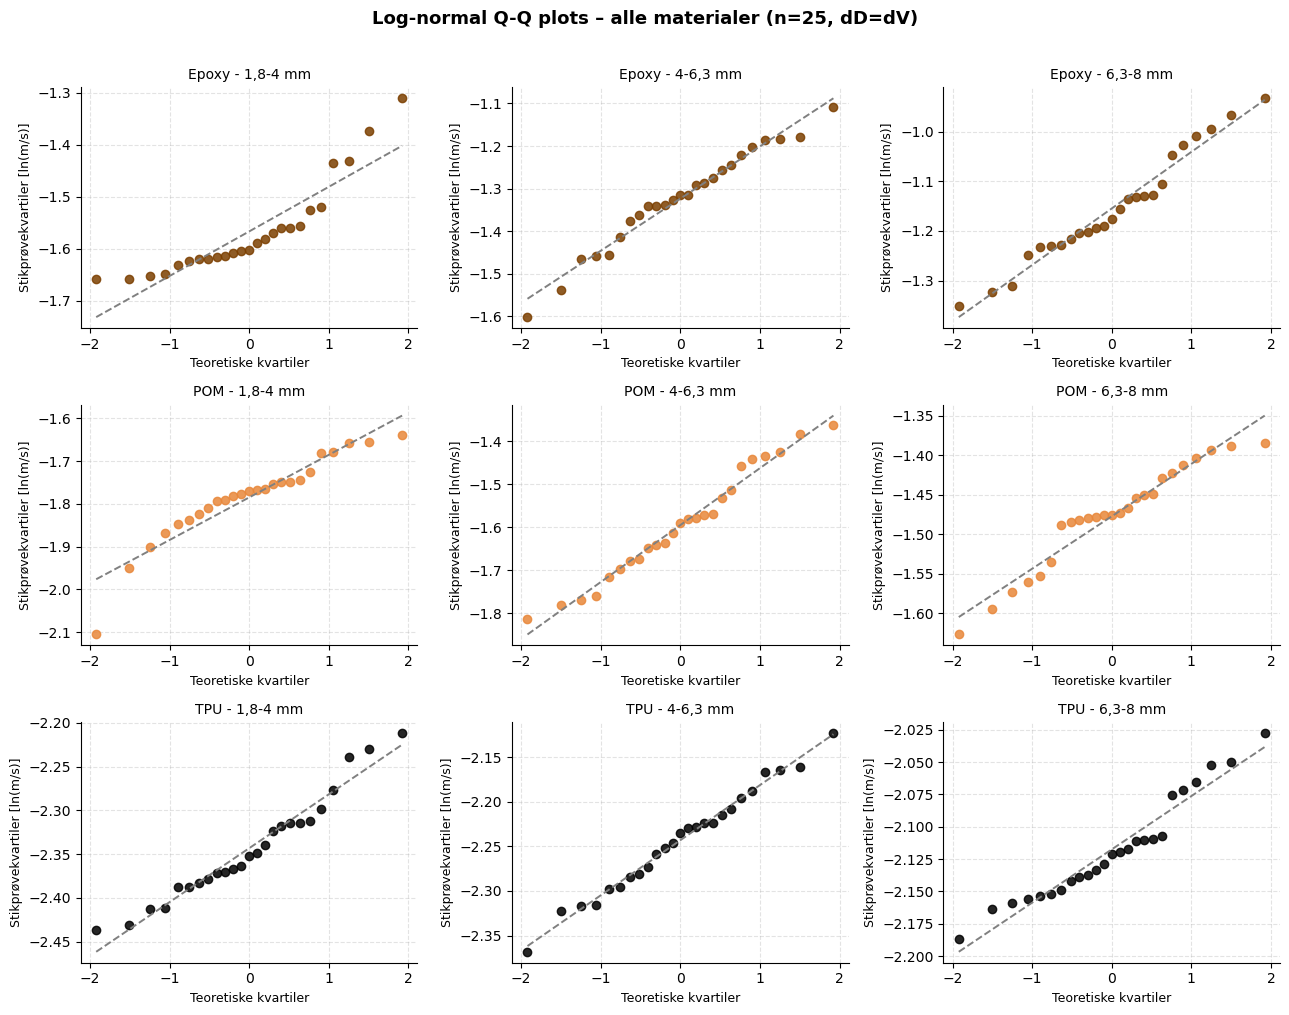

Gemt: ../fig_qq_lognormal_dV.png


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
fig.suptitle(
    'Log-normal Q-Q plots – alle materialer (n=25, dD=dV)',
    fontsize=13, fontweight='bold', y=1.01
)

for row, mat in enumerate(MATS):
    data_list, rho_p = RAW[mat]
    color = COLORS[mat]
    for col, (raw, sieve) in enumerate(zip(data_list, SIEVES)):
        ax = axes[row, col]
        v  = get_velocities(raw, rho_p, dD='dV')
        plot_lognormal_qq(ax, v, color)
        ax.set_title(f'{mat} - {sieve}', fontsize=10)

fig.tight_layout()
fig.savefig('../fig_qq_lognormal_dV.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Gemt: ../fig_qq_lognormal_dV.png')

## dD = c

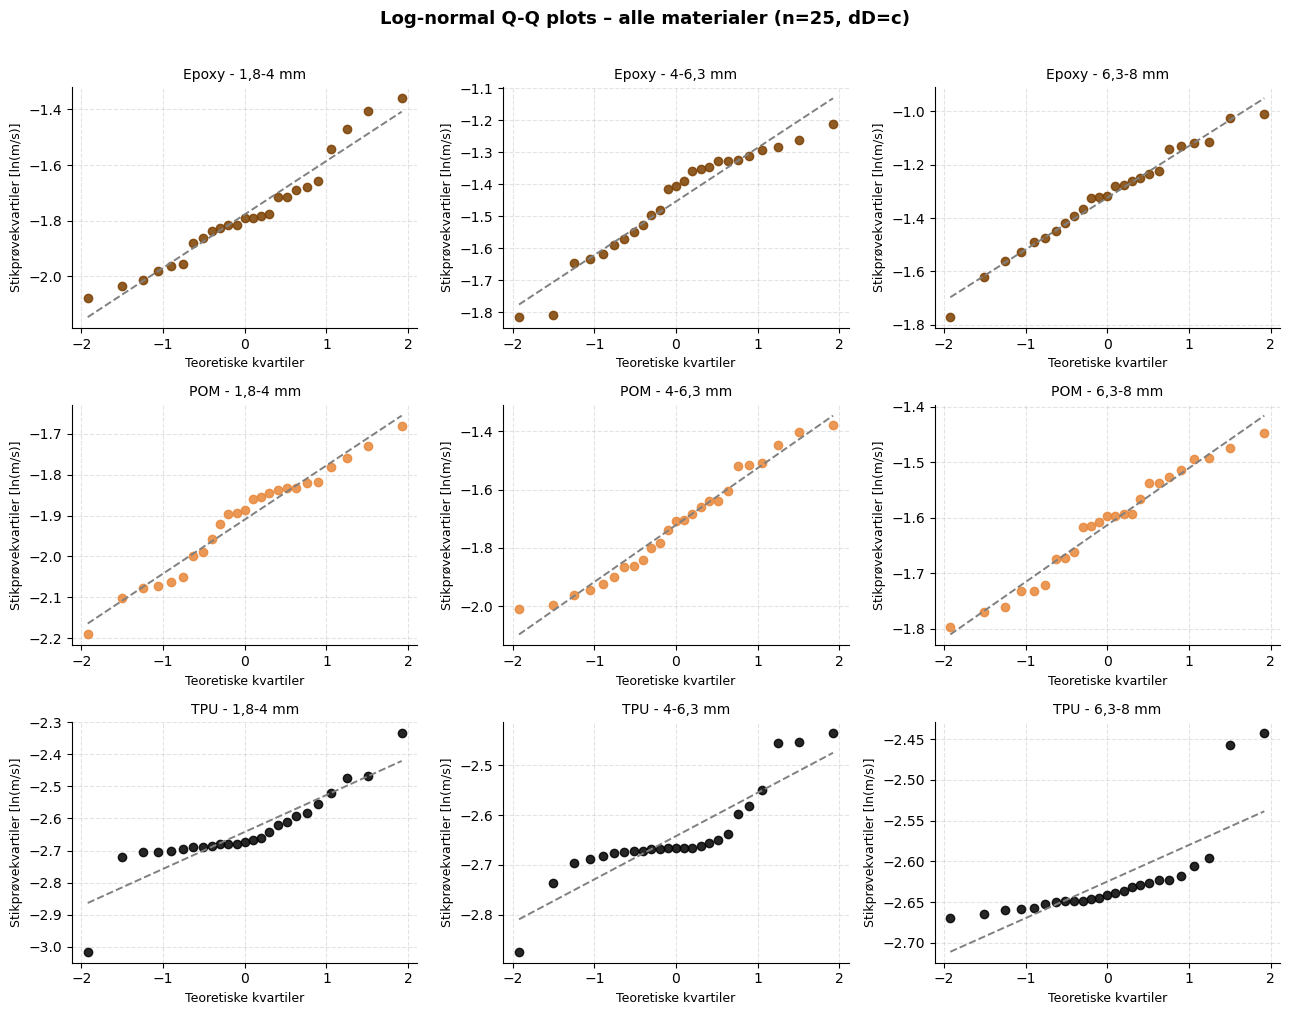

Gemt: ../fig_qq_lognormal_c.png


In [7]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
fig.suptitle(
    'Log-normal Q-Q plots – alle materialer (n=25, dD=c)',
    fontsize=13, fontweight='bold', y=1.01
)

for row, mat in enumerate(MATS):
    data_list, rho_p = RAW[mat]
    color = COLORS[mat]
    for col, (raw, sieve) in enumerate(zip(data_list, SIEVES)):
        ax = axes[row, col]
        v  = get_velocities(raw, rho_p, dD='c')
        plot_lognormal_qq(ax, v, color)
        ax.set_title(f'{mat} - {sieve}', fontsize=10)

fig.tight_layout()
fig.savefig('../fig_qq_lognormal_c.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Gemt: ../fig_qq_lognormal_c.png')